# Notebook 15: CNN Image Classification



## 1. Dataset Loading and Visualization

Fashion-MNIST images are $28 \times 28$ pixels.

In [2]:
%pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


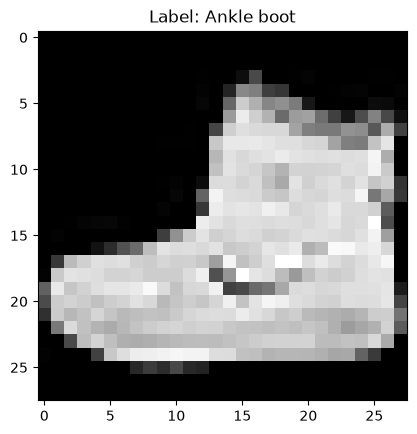

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Normalization and Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale pixels to [-1, 1]
])

train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# Visualization
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
img, label = train_set[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {classes[label]}")
plt.show()

## 2. CNN Architecture

We will use a standard architecture:
- **Conv Layer 1:** 3 input channels $\rightarrow$ 16 filters ($3 \times 3$).
- **Max Pool:** $2 \times 2$.
- **Conv Layer 2:** 16 filters $\rightarrow$ 32 filters ($3 \times 3$).
- **Max Pool:** $2 \times 2$.
- **Flatten** $\rightarrow$ **Dense Layer** $\rightarrow$ **Softmax**.

In [5]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Layer 1: (1, 28, 28) -> (16, 26, 26) -> (16, 13, 13)
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Layer 2: (16, 13, 13) -> (16, 11, 11) -> (16, 5, 5)
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = FashionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.5149
Epoch 2/5, Loss: 0.3406
Epoch 3/5, Loss: 0.2937
Epoch 4/5, Loss: 0.2621
Epoch 5/5, Loss: 0.2400


## 3. Evaluation and Error Analysis

We will check accuracy and visualize misclassified images.

Test Accuracy: 0.8942


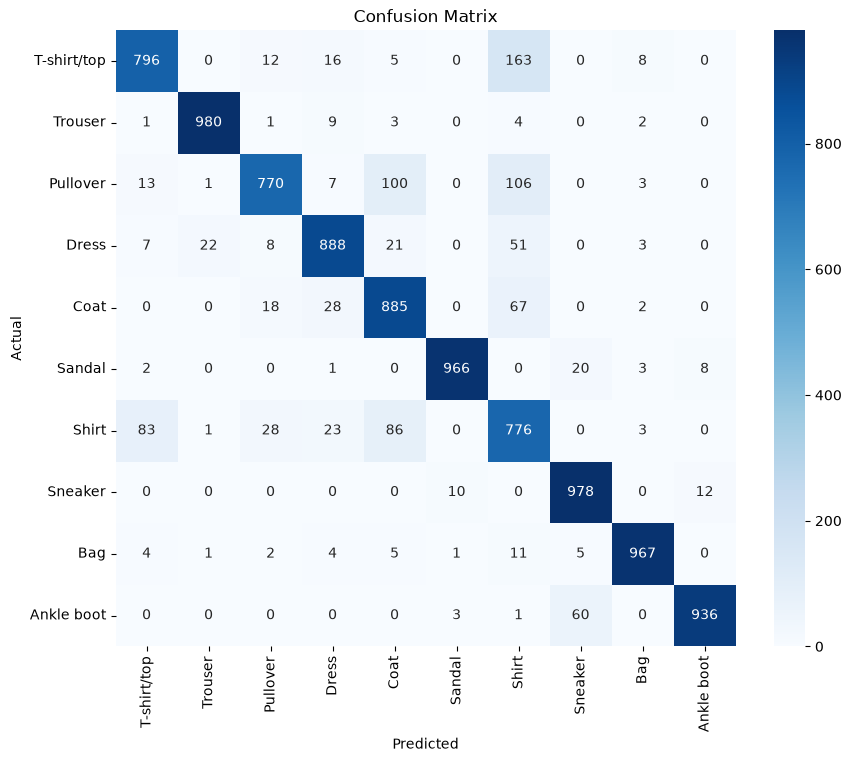

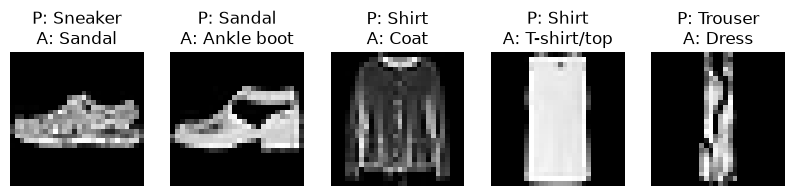

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.tolist())
        all_labels.extend(labels.tolist())

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Misclassified Images
misclassified_idx = np.where(np.array(all_preds) != np.array(all_labels))[0]
plt.figure(figsize=(10, 4))
for i in range(5):
    idx = misclassified_idx[i]
    img, label = test_set[idx]
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"P: {classes[all_preds[idx]]}\nA: {classes[label]}")
    plt.axis('off')
plt.show()

**Interpretation:**
Incorrect predictions often happen between visually similar classes (e.g., "Coat" vs "Pullover" or "T-shirt" vs "Shirt"). This is because the model struggles with fine-grained differences in texture and shape.